# Contextual String Embeddings for Sequence Labeling
**Akbik, Blythe & Vollgraf — COLING 2018**

This notebook implements the paper using the **official pretrained character language models**
released by the authors, loaded via the [Flair](https://github.com/flairNLP/flair) library.

The key difference from the previous notebook is that **Stage 1 (LM pre-training) is skipped entirely** — we load the same LMs the authors trained on the 1-billion word corpus, so every embedding we extract is faithful to the paper.

## Prerequisites

```bash
pip install flair datasets seqeval evaluate
```

The first time cell 2 runs, Flair will download two `.pt` files (~30 MB each):
- `news-forward-fast` — forward character LM trained on 1B-word news corpus
- `news-backward-fast` — backward character LM trained on 1B-word news corpus

These are the exact models used to produce the **93.09 F1** result in the paper.

---

## 0. Imports & Setup

In [139]:
!pip install flair datasets seqeval evaluate

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import warnings
import evaluate
from datasets import load_dataset
from typing import List, Tuple, Dict, Optional
from collections import defaultdict

metric = evaluate.load("seqeval")
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

import flair
from flair.embeddings import FlairEmbeddings, StackedEmbeddings
from flair.data import Sentence
flair.device = DEVICE
print(f'Flair  : {flair.__version__}')

Device : cpu
PyTorch: 2.11.0
Flair  : 0.15.1


## 1. Load the Pretrained Character Language Models

The Flair library ships `FlairEmbeddings`, which wraps exactly the character-level LMs from the paper.
Internally each `FlairEmbeddings` object holds a trained `LanguageModel` (the LSTM described in §2.1).

| String | Description |
|---|---|
| `'news-forward'` | Forward LM, trained on 1B-word English news corpus (same as paper) |
| `'news-backward'` | Backward LM, same corpus |

The first call downloads the weights once and caches them in `~/.flair/embeddings/`.

In [3]:
# create a StackedEmbedding object that combines glove and forward/backward flair embeddings
stacked_embeddings = StackedEmbeddings([
                                        FlairEmbeddings('news-forward-fast'),
                                        FlairEmbeddings('news-backward-fast'),
                                       ])

sentence = Sentence('The grass is green .')

# just embed a sentence using the StackedEmbedding as you would with any single embedding.
stacked_embeddings.embed(sentence)

# now check out the embedded tokens.
for token in sentence:
    print(token)
    print(token.embedding)

Token[0]: "The"
tensor([ 2.1388e-03, -1.0227e-06, -5.7348e-03,  ...,  5.0093e-10,
        -3.5811e-07,  4.0297e-01])
Token[1]: "grass"
tensor([-8.7856e-04, -4.2676e-05,  2.4843e-02,  ...,  4.6339e-09,
        -2.1093e-07, -7.9564e-02])
Token[2]: "is"
tensor([ 1.8401e-03, -2.0841e-04,  2.9775e-02,  ...,  2.2809e-08,
         1.6601e-08, -2.7504e-01])
Token[3]: "green"
tensor([-4.1963e-04, -1.5563e-05,  4.5961e-03,  ...,  2.1851e-10,
         1.1094e-07, -1.8823e-02])
Token[4]: "."
tensor([ 8.2723e-04, -2.9691e-06,  4.9718e-03,  ...,  7.2283e-10,
         1.9171e-07, -1.5373e-02])


# Questions:

- What is the embedding dimension of the language model?

# Excercise:

- Embed the two sentences below and retrieve the embedding vector for the word 'Apple' in each.  Compute the cosine similarity between the two vectors.

Expected insight: the same word should have DIFFERENT embeddings in each context because the character LM has seen different left/right characters.

In [24]:
from torch.nn.functional import cosine_similarity

s1 = Sentence('Steve Jobs founded Apple .')
s2 = Sentence('Marie found an apple .')

stacked_embeddings.embed(s1)
stacked_embeddings.embed(s2)

# TODO: retrieve the embedding of 'apple' (index 5) from both sentences
apple_s1 = s1.tokens[3].embedding
apple_s2 = s2.tokens[3].embedding

# TODO: compute cosine similarity (both vectors need shape (1, D))
sim = cosine_similarity(apple_s1.unsqueeze(0), apple_s2.unsqueeze(0))
print(f'Cosine similarity of \"apple\" across contexts: {sim.item():.4f}')
print('Are the embeddings identical?', torch.allclose(apple_s1, apple_s2))

Cosine similarity of "apple" across contexts: 0.5706
Are the embeddings identical? False


## 2. Load CoNLL-2003


In [25]:
def hf_to_sentences(hf_split, id2label: Dict[int, str]) -> List[List[Tuple[str, str]]]:
    """Convert a HuggingFace conll2003 split to (token, tag) lists."""
    sentences = []
    for ex in hf_split:
        sent = [(tok, id2label[tag]) for tok, tag in zip(ex['tokens'], ex['ner_tags'])]
        sentences.append(sent)
    return sentences

train_sentences = load_dataset("eriktks/conll2003",revision="convert/parquet",split="train[:5000]")
dev_sentences = load_dataset("eriktks/conll2003",revision="convert/parquet",split="validation[:500]")
test_sentences = load_dataset("eriktks/conll2003",revision="convert/parquet",split="test[:500]")

labels = train_sentences["ner_tags"].features.feature.names
id2label = {i: l for i, l in enumerate(labels)}
train_sentences = hf_to_sentences(train_sentences, id2label)
dev_sentences   = hf_to_sentences(dev_sentences, id2label)
test_sentences  = hf_to_sentences(test_sentences, id2label)

# Questions
- Why does class imbalance matter for NER evaluation?
- what accuracy vs F1 would show on a naive "predict O always" baseline

In [28]:
from collections import Counter

label_counts = Counter()
for sent in train_sentences:
    for _, tag in sent:
        label_counts[tag] += 1

print('Label distribution in training set:')
for label, count in label_counts.most_common():
    print(f'  {label:<12} {count:>6}')

print()
total = sum(label_counts.values())
o_pct = label_counts['O'] / total * 100
print(f'Fraction of tokens labelled \"O\": {o_pct:.1f}%')

Label distribution in training set:
  O             55196
  B-LOC          2768
  B-PER          2584
  B-ORG          2058
  I-PER          1875
  B-MISC         1236
  I-ORG          1105
  I-MISC          455
  I-LOC           357

Fraction of tokens labelled "O": 81.6%


## 3. Extracting Contextual String Embeddings (§2.2, Eq. 8)

We now use **Flair's own extraction logic** directly, which is the reference implementation.
The `FlairEmbeddings.embed()` method:
1. Converts a sentence to a character sequence
2. Runs it through the pretrained LSTM
3. Reads off hidden states at word boundaries — exactly Eq. (8)

Here we show how to access those embeddings as raw PyTorch tensors.

In [33]:
def make_flair_sentence(word_tag_pairs: List[Tuple[str, str]]) -> Sentence:
    """Convert a list of (word, tag) tuples to a Flair Sentence object."""
    words = [w for w, _ in word_tag_pairs]
    return Sentence(words)


def embed_sentence(word_tag_pairs: List[Tuple[str, str]]) -> torch.Tensor:
    """
    Extract contextual string embeddings for all words in a sentence.

    Uses the pretrained forward + backward LMs.
    Returns a tensor of shape (num_words, 2 * hidden_size).

    This reproduces the operation in Eq. (8) of the paper:
        w_i^CharLM = [ h^f_{t_{i+1}-1} ; h^b_{t_i - 1} ]
    """
    sentence = make_flair_sentence(word_tag_pairs)

    # Each embed() call runs the character LM and stores a vector on each token
    stacked_embeddings.embed(sentence)

    # Each token now has a .embedding of size 2 * hidden_size
    # (Flair concatenates fwd + bwd automatically when both are called)
    token_embeddings = torch.stack(
        [token.embedding for token in sentence.tokens], dim=0
    )  # (n_words, 2 * hidden_size)

    # Detach from graph — the LM is frozen
    return token_embeddings.detach()


# ── Sanity check ───────────────────────────────────────────────────────────
example = train_sentences[0]
emb = embed_sentence(example)
EMB_DIM = emb.size(1)
print('Sentence :', [w for w, _ in example])
print(f'Embedding dimension: {EMB_DIM}')
print(f'Embedding dtype: {emb.dtype}')
print(f'Embedding device: {emb.device}')

Sentence : ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
Embedding dimension: 2048
Embedding dtype: torch.float32
Embedding device: cpu


## 4. Label Vocabulary

In [38]:
class Vocabulary:
    def __init__(self, specials=None):
        self.item2idx: Dict[str, int] = {}
        self.idx2item: List[str] = []
        if specials:
            for s in specials: self.add(s)

    def add(self, item):
        if item not in self.item2idx:
            self.item2idx[item] = len(self.idx2item)
            self.idx2item.append(item)
        return self.item2idx[item]

    def __getitem__(self, item):
        return self.item2idx.get(item, 0)

    def __len__(self):
        return len(self.idx2item)


label_vocab = Vocabulary()
for sent in train_sentences + dev_sentences + test_sentences:
    for _, tag in sent: label_vocab.add(tag)

print(f'NER labels ({len(label_vocab)}): {label_vocab.idx2item}')
print(f'Embedding dim (fwd + bwd)  : {EMB_DIM}')

NER labels (9): ['B-ORG', 'O', 'B-MISC', 'B-PER', 'I-PER', 'B-LOC', 'I-ORG', 'I-MISC', 'I-LOC']
Embedding dim (fwd + bwd)  : 2048


## 5. BiLSTM-CRF Sequence Labeler (§2.3)

The sequence labeler is **trained from scratch** on CoNLL-03 labels.
Only the LM weights are frozen — the BiLSTM and CRF are learned on the labeled data.

In [39]:
class NERTagger(nn.Module):
    """
    BiLSTM tagger with:
      - token-level cross entropy
      - greedy decoding
      - batched loss computation
      - optional ignoring of "O" labels in the loss
    """

    def __init__(
        self,
        emb_dim,
        num_labels,
        bilstm_hidden=256,
        bilstm_layers=1,
        dropout=0.25,
    ):
        super().__init__()

        self.num_labels = num_labels

        self.drop = nn.Dropout(dropout)

        self.bilstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=bilstm_hidden,
            num_layers=bilstm_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if bilstm_layers > 1 else 0.0,
        )

        self.linear = nn.Linear(2 * bilstm_hidden, num_labels)

    # ── utilities ────────────────────────────────────────────────────────
    def _pad_batch(self, emb_list):
        """
        emb_list:
            list[(L_i, D)]

        returns:
            padded:  (B, Lmax, D)
            lengths: list[int]
        """
        max_len = max(e.size(0) for e in emb_list)
        batch_size = len(emb_list)
        emb_dim = emb_list[0].size(1)

        padded = torch.zeros(
            batch_size,
            max_len,
            emb_dim,
            device=DEVICE,
        )

        lengths = []

        for i, e in enumerate(emb_list):
            L = e.size(0)

            padded[i, :L] = e.to(DEVICE)
            lengths.append(L)

        return padded, lengths

    def _pad_tags(self, tag_seqs, max_len):
        """
        Create padded target tensor.
        """
        targets = torch.full(
            (len(tag_seqs), max_len),
            fill_value=-100,
            dtype=torch.long,
            device=DEVICE,
        )

        for i, tags in enumerate(tag_seqs):
            targets[i, :len(tags)] = torch.tensor(
                tags,
                dtype=torch.long,
                device=DEVICE,
            )

        return targets

    # ── forward ──────────────────────────────────────────────────────────
    def forward(self, emb_list):
        """
        returns:
            logits: (B, L, K)
            lengths: list[int]
        """
        padded, lengths = self._pad_batch(emb_list)

        lstm_out, _ = self.bilstm(self.drop(padded))

        logits = self.linear(self.drop(lstm_out))

        return logits, lengths

    # ── batched loss ─────────────────────────────────────────────────────
    def loss(self, emb_list, tag_seqs):
        """
        Batched token-level cross entropy.

        Ignores:
          - padding positions
          - all tokens with gold label == O
        """
        logits, lengths = self.forward(emb_list)

        B, L, K = logits.shape

        targets = self._pad_tags(tag_seqs, L)

        # flatten for CE
        logits = logits.reshape(B * L, K)
        targets = targets.reshape(B * L)

        loss = F.cross_entropy(
            logits,
            targets,
        )

        return loss

    # ── greedy decoding ─────────────────────────────────────────────────
    @torch.no_grad()
    def predict_from_embs(self, emb_list):
        self.eval()

        logits, lengths = self.forward(emb_list)

        predictions = []

        for i, L in enumerate(lengths):
            pred = logits[i, :L].argmax(dim=-1)
            predictions.append(pred.cpu().tolist())

        return predictions


# ── Instantiate ──────────────────────────────────────────────────────────


tagger = NERTagger(
    emb_dim=EMB_DIM,
    num_labels=len(label_vocab),
    bilstm_hidden=256,
)

tagger.to(DEVICE)

NERTagger(
  (drop): Dropout(p=0.25, inplace=False)
  (bilstm): LSTM(2048, 256, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=512, out_features=9, bias=True)
)

In [43]:
# Create two dummy embedding tensors
dummy_embs = [
    torch.randn(6, EMB_DIM),
    torch.randn(4, EMB_DIM),
]

tagger.eval()
with torch.no_grad():
    logits, lengths = tagger.forward(dummy_embs)

# Questions:
- What is the shape of logits?
- What is padding? Why is it necessary?
- What is the role of the fill_value=-100 in _pad_tags?
- What are the predicted tags (i.e. the index of the highest logit per sentence)?

## 6. Pre-computing Embeddings

Running the character LM on every sentence at each training epoch is slow.
Since the LM is **frozen**, we compute all embeddings once and cache them — this is
the standard practice when fine-tuning on top of frozen pretrained representations.

In [41]:
def precompute_embeddings(sentences, desc=''):
    """Run Flair LMs once over all sentences; return list of (L_i, D) tensors."""
    embs   = []
    errors = 0
    for i, sent in enumerate(sentences):
        if i % 500 == 0 and i > 0:
            print(f'  {desc}: {i}/{len(sentences)} ...')
        try:
            embs.append(embed_sentence(sent))
        except Exception as ex:
            embs.append(torch.zeros(len(sent), EMB_DIM))
            errors += 1
    if errors:
        print(f'  Warning: {errors} sentences failed embedding, replaced with zeros.')
    return embs


print('Pre-computing train embeddings...')
train_embs = precompute_embeddings(train_sentences, 'train')
print('Pre-computing dev   embeddings...')
dev_embs   = precompute_embeddings(dev_sentences,   'dev')
print('Pre-computing test  embeddings...')
test_embs  = precompute_embeddings(test_sentences,  'test')

train_tags = [[label_vocab[tag] for _, tag in sent] for sent in train_sentences]
dev_tags   = [[label_vocab[tag] for _, tag in sent] for sent in dev_sentences]
test_tags  = [[label_vocab[tag] for _, tag in sent] for sent in test_sentences]

print(f'\nDone. Example embedding shape: {train_embs[0].shape}')

Pre-computing train embeddings...
  train: 500/5000 ...
  train: 1000/5000 ...
  train: 1500/5000 ...
  train: 2000/5000 ...
  train: 2500/5000 ...
  train: 3000/5000 ...
  train: 3500/5000 ...
  train: 4000/5000 ...
  train: 4500/5000 ...
Pre-computing dev   embeddings...
Pre-computing test  embeddings...

Done. Example embedding shape: torch.Size([9, 2048])


## Questions:


- The embeddings are pre-computed *once* and cached as Python lists of tensors. Why is this only valid because the LM is **frozen**? What would break if you were fine-tuning the LM during training?
- Estimate the memory footprint (in MB) of `train_embs`. **Hint**: You know / assume: 5000 sentences, average ~18 word each, `EMB_DIM` = 2048, dtype = float32.
- What would you do, if the size of the pre-computed embeddings exceeded your GPUs memory?

## 7. Training (§3.2)

In [47]:
def evaluate(tagger, emb_list, sentences):
    """Span-level F1 using seqeval (paper's metric)."""
    pred_ids = tagger.predict_from_embs(emb_list)
    preds    = [[label_vocab.idx2item[t] for t in ids] for ids in pred_ids]
    gold     = [[tag for _, tag in sent] for sent in sentences]
    return metric.compute(predictions=preds, references=gold)["overall_f1"]


def train(tagger, train_embs, train_tags, dev_embs, dev_sentences,
          epochs=100, lr=0.1, clip=5.0, batch_size=32, anneal_patience=5):
    opt           = optim.SGD(tagger.parameters(), lr=lr)
    best_f1       = -1
    patience      = 0
    train_losses  = []
    dev_f1s       = []

    for epoch in range(1, epochs + 1):
        tagger.train()
        order = list(range(len(train_embs)))
        random.shuffle(order)
        total = 0.0
        n_batches = 0

        for start in range(0, len(order), batch_size):
            idx      = order[start:start + batch_size]
            b_embs   = [train_embs[i] for i in idx]
            b_tags   = [train_tags[i] for i in idx]
            opt.zero_grad()
            loss = tagger.loss(b_embs, b_tags)
            loss.backward()
            nn.utils.clip_grad_norm_(tagger.parameters(), clip)
            opt.step()
            total     += loss.item()
            n_batches += 1

        avg_loss = total / n_batches
        f1 = evaluate(tagger, dev_embs, dev_sentences)
        train_losses.append(avg_loss)
        dev_f1s.append(f1)

        # Learning rate annealing (paper §3.2)
        if f1 > best_f1:
            best_f1  = f1
            patience = 0
        else:
            patience += 1
            if patience >= anneal_patience:
                for pg in opt.param_groups:
                    pg['lr'] *= 0.5
                    if pg['lr'] < 1e-5:
                        print("Stop Training")
                        break
                patience = 0

        if epoch % 10 == 0:
            current_lr = opt.param_groups[0]['lr']
            print(f'Epoch {epoch:3d} | loss {avg_loss:.4f} | dev F1 {f1:.4f} | best {best_f1:.4f} | lr {current_lr:.5f}')

    return train_losses, dev_f1s


print('Training BiLSTM on frozen Flair embeddings...')
train_losses, dev_f1s = train(
    tagger, train_embs, train_tags, dev_embs, dev_sentences,
    epochs=100, lr=0.1, clip=5.0, batch_size=32
)

Training BiLSTM on frozen Flair embeddings...
Epoch  10 | loss 0.2170 | dev F1 0.6842 | best 0.6842 | lr 0.10000
Epoch  20 | loss 0.1431 | dev F1 0.7763 | best 0.7763 | lr 0.10000
Epoch  30 | loss 0.1082 | dev F1 0.8436 | best 0.8436 | lr 0.10000
Epoch  40 | loss 0.0906 | dev F1 0.8688 | best 0.8700 | lr 0.10000
Epoch  50 | loss 0.0774 | dev F1 0.8723 | best 0.8791 | lr 0.10000
Epoch  60 | loss 0.0693 | dev F1 0.8723 | best 0.8791 | lr 0.02500
Epoch  70 | loss 0.0679 | dev F1 0.8735 | best 0.8791 | lr 0.00625
Epoch  80 | loss 0.0680 | dev F1 0.8773 | best 0.8791 | lr 0.00156
Epoch  90 | loss 0.0681 | dev F1 0.8762 | best 0.8791 | lr 0.00039
Epoch 100 | loss 0.0670 | dev F1 0.8751 | best 0.8791 | lr 0.00010


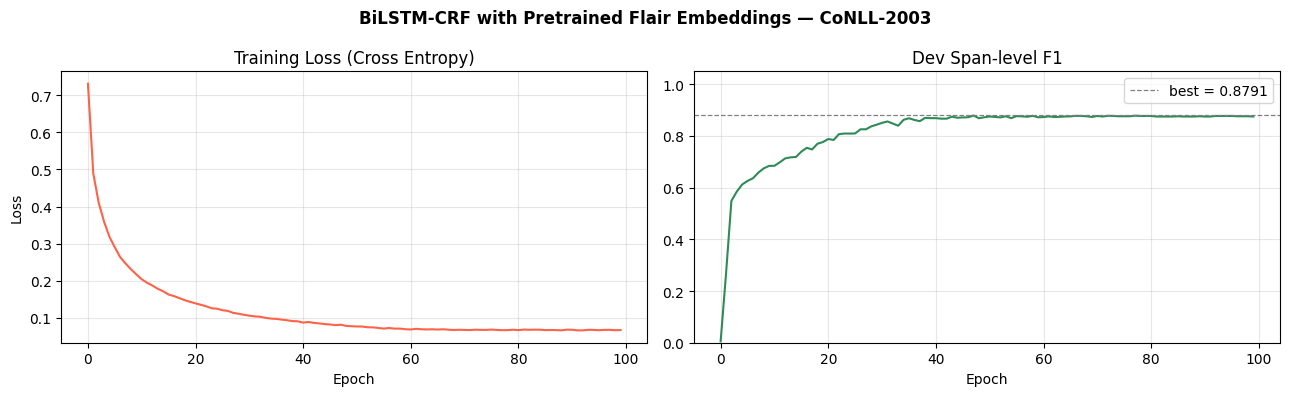

In [48]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))

a1.plot(train_losses, color='tomato')
a1.set_title('Training Loss (Cross Entropy)'); a1.set_xlabel('Epoch'); a1.set_ylabel('Loss'); a1.grid(alpha=.3)

a2.plot(dev_f1s, color='seagreen')
a2.axhline(max(dev_f1s), ls='--', color='gray', lw=.9, label=f'best = {max(dev_f1s):.4f}')
a2.set_title('Dev Span-level F1'); a2.set_xlabel('Epoch')
a2.set_ylim(0, 1.05); a2.legend(); a2.grid(alpha=.3)

plt.suptitle('BiLSTM-CRF with Pretrained Flair Embeddings — CoNLL-2003', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Test Set Evaluation

In [49]:
evaluate(tagger, test_embs, test_sentences)

np.float64(0.8344172086043022)